# **EmoVision - See Your Emotion, Understand Yourself**

####**ID Tim Capstone Project : CC26-PSU392**

> Emovision adalah proyek yang mengembangkan sebuah webiste yang memiliki fitur utama dalam mendeteksi 7 emosi manusia  (angry, disgust, fear, happy, neutral, sad, dan surprise) melalui teks journaling dan gambar wajah. Oleh karena itu, proyek ini membutuhkan sebuah dataset yang berisikan beberapa teks yang telah dilabeling ke-7 emosi tersebut.

----

**Berikut adalah pertanyaan yang dapat diukur melalui dataset teks proyek EmoVision :**
1. Kata emosi apa yang paling sering muncul pada emosi **angry?**
2. Kata emosi apa yang paling sering muncul pada emosi **disgust?**
3. Kata emosi apa yang paling sering muncul pada emosi **fear?**
4. Kata emosi apa yang paling sering muncul pada emosi **happy?**
5. Kata emosi apa yang paling sering muncul pada emosi **neutral?**
6. Kata emosi apa yang paling sering muncul pada emosi **sad?**
7. Kata emosi apa yang paling sering muncul pada emosi **surprise?**

**CONNECT TO GOOGLE DRIVE**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = '/content/drive/MyDrive/Dataset - Teks/Data Mentah Teks - New.csv'

**Import Modul**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

#### **1. LOAD DATA**

In [ ]:
# Load Data

data_df = pd.read_csv(DATASET_PATH)

data_df.head(10)

,full_text
0,sialan memang
1,benci bgt ama hrd kek gini
2,benci banget tiap ada yang bawa narasi begitu....
3,@jstforplay @tpwkindnhes BENCI BANGET HARRY MY...
4,benci ah gatal camni
5,benci banget sama TL gue gue lg begini main di...
6,@KuaciChi Terimakasih kembali effortnya kak. S...
7,Wkwkwk anying emang bener ternyata. Yang renta...
8,@zakariamlk Nyetrika sih jujur benci banget se...
9,sialan gue kangen marhoon banget ADUH UTBK KAT...


#### **2. EDA DATA RAW / ASSESSING DATA**

In [ ]:
print("Jumlah data :", len(data_df))

Jumlah data : 7347


> **Insight :** Dataset mentah hasil scrapping memiliki jumlah data 7347, dataset ini belum melalui proses cleaning apapun





In [ ]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7347 entries, 0 to 7346
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  7347 non-null   object
dtypes: object(1)
memory usage: 57.5+ KB


> **Insight :** Terlihat bahwa dataset ini tidak memiliki Missing Values dan Type Data pada kolom full_text juga sudah benar, yaitu 'object'

In [ ]:
data_df.isnull().sum()

,0
full_text,0


>  **Insight :** Tidak ditemukannya missing value

In [ ]:
data_df.duplicated().sum()

np.int64(462)

> **Insight :** Terdapat duplikasi teks pada dataset ini, yaitu berjumlah 462 baris teks

In [ ]:
# Menghitung jumlah karakter tiap baris
data_df['panjang_karakter'] = data_df['full_text'].astype(str).apply(len)

In [ ]:
# Menghitung jumlah kata tiap baris
data_df['jumlah_kata'] = data_df['full_text'].astype(str).apply(lambda x: len(x.split()))

In [ ]:
# Melihat ringkasan statistik
display(data_df[['panjang_karakter', 'jumlah_kata']].describe())

,panjang_karakter,jumlah_kata
count,7347.000000,7347.000000
mean,104.188512,16.543351
std,80.987858,13.249922
min,3.000000,1.000000
25%,40.000000,6.000000
50%,75.000000,12.000000
75%,152.000000,24.000000
max,443.000000,72.000000


> **Insight :** Dapat diketahui bahwa terdapat satu baris yang hanya memiliki 1 kata, yang mana dari 1 kata tersebut bisa saja tidak memiliki arti emosi apapun, sehingga nantinya pada saat cleaning dapat dihapuskan

In [ ]:
# Menggabungkan semua teks menjadi satu string panjang
semua_teks = ' '.join(data_df['full_text'].astype(str).tolist())

# Memisahkan string menjadi kata-kata
semua_kata = semua_teks.split()

frekuensi_kata = Counter(semua_kata)
print("20 Kata Paling Sering Muncul:")
print(frekuensi_kata.most_common(20))

20 Kata Paling Sering Muncul:
[('di', 1041), ('aku', 983), ('yang', 954), ('ini', 949), ('yg', 948), ('banget', 830), ('dan', 820), ('ga', 805), ('bgt', 790), ('ada', 664), ('sama', 652), ('aja', 639), ('ya', 630), ('itu', 620), ('tapi', 515), ('bisa', 512), ('dia', 493), ('nangis', 479), ('gw', 476), ('gue', 464)]


> **Insight :** Dapat diketahui bahwa kata yang sering muncul pada dataset ini adalah kata yang bersifat stopword, seperti di, yang, ini, banget, dan, ga. Dari sini kita dapat mengetahui bahwa terdapat unsur stopword yang sangat banyak pada dataset ini, sehingga pada saat cleaning dapat dipertimbangkan akan melakukan penghapusan stopword atau tidak.

In [ ]:
# Melihat 2 kata urutan yang sering muncul

vectorizer = CountVectorizer(ngram_range=(2, 2)) # Mengambil tepat 2 kata berurutan (Bigram)
X_bigram = vectorizer.fit_transform(data_df['full_text'].astype(str)) # Fit transform data teks
sum_words = X_bigram.sum(axis=0) # jumlahkan
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True) # Mengurutkan

print("15 Urutan Kata (Bigram) Paling Sering Muncul:")
for word, freq in words_freq[:50]:
    print(f"{word}: {freq}")

15 Urutan Kata (Bigram) Paling Sering Muncul:
https co: 933
hari ini: 134
sedih bgt: 85
ada yang: 74
seneng banget: 74
ada yg: 69
ya allah: 59
sedih banget: 59
jijik bgt: 57
mau nangis: 56
najis bgt: 55
ga ada: 52
ngeri banget: 50
seneng bgt: 49
jijik banget: 48
tiba tiba: 41
lucu banget: 40
orang yang: 39
aku juga: 36
banget ya: 36
ya kak: 36
takut bgt: 35
jangan khawatir: 35
tiap hari: 34
benci bgt: 33
orang lain: 33
yang bikin: 33
banget sih: 33
banget sama: 32
takut banget: 32
salah satu: 31
yg bikin: 31
ngakak bgt: 30
bener bener: 30
terima kasih: 30
marah marah: 29
nangis di: 29
gak ada: 29
orang orang: 29
aku ga: 29
ga pernah: 28
najis banget: 28
ikut seneng: 28
this is: 27
aku udah: 26
perlu khawatir: 26
ga bisa: 25
aku mau: 25
benci banget: 24
ada aja: 24


> **Insight :** melalui pengecekan 2 kata berurutan yang paling sering muncul ini, kita menjadi tahu bahwa terdapat kata yang mengandung salah satu kata kunci emosi, yaitu 'jangan khawatir', biasanya ini akan terdeteksi menjadi emosi fear, dengan kita mengecek ini, nantinya pada saat melakukan sastrawi/labeling, kita akan mengatur bahwa 2 kata tersebut bukan mengandung emosi fear, melainkan emosi lain dikarenakan terdapat kata negasi 'jangan'.

In [ ]:
# Mendeteksi kata CAPSLOCK
data_df['capslock'] = data_df['full_text'].astype(str).apply(lambda x: bool(re.search(r'\b[A-Z]{3,}\b', x)))

# Mendeteksi tanda baca ekstrem
data_df['ekstrem_tanda_baca'] = data_df['full_text'].astype(str).apply(lambda x: bool(re.search(r'[!?]{2,}', x)))

# Dijumlahkan
jumlah_capslock = data_df['capslock'].sum()
jumlah_tanda_baca = data_df['ekstrem_tanda_baca'].sum()
total_data = len(data_df)

print(f"Tweet mengandung kata CAPSLOCK: {jumlah_capslock} dari {total_data} data ({(jumlah_capslock/total_data)*100:.2f}%)")
print(f"Tweet mengandung Tanda Baca Ekstrem: {jumlah_tanda_baca} dari {total_data} data ({(jumlah_tanda_baca/total_data)*100:.2f}%)")

Tweet mengandung kata CAPSLOCK: 1348 dari 7347 data (18.35%)
Tweet mengandung Tanda Baca Ekstrem: 256 dari 7347 data (3.48%)


> **Insight :** melalui pengecekan jumlah kata kapital ini menjadi tahu bahwa nanti nya akan tetap melalukan case folding atau tidak, karena melalui labeling nanti menggunakan kata kunci emosi saja, bukan menggunakan kata tersebut capslock atau tidak dan menggunakan tanda baca ekstrim atau tidak

In [ ]:
# Mendeteksi keberadaan Mention
data_df['mention'] = data_df['full_text'].astype(str).str.contains(r'@\w+', regex=True)

# Mendeteksi keberadaan Hashtag
data_df['hashtag'] = data_df['full_text'].astype(str).str.contains(r'#\w+', regex=True)

# Mendeteksi keberadaan Link/URL
data_df['url'] = data_df['full_text'].astype(str).str.contains(r'http\S+|www\.\S+', regex=True)

print(f"Jumlah Tweet dengan Mention (@) : {data_df['mention'].sum()}")
print(f"Jumlah Tweet dengan Hashtag (#) : {data_df['hashtag'].sum()}")
print(f"Jumlah Tweet dengan Link (URL)  : {data_df['url'].sum()}")

Jumlah Tweet dengan Mention (@) : 3607
Jumlah Tweet dengan Hashtag (#) : 311
Jumlah Tweet dengan Link (URL)  : 888


> **Insight :** Melalui pengecekan jumlah mention, hashtag, dan link URL, kita menjadi tahu bahwa dataset ini masih memiliki noise yang beragam, yang mana noise tersebut dapat menggangu proses labeling di akhir nanti. Bahkan dapat menggangu privasi data user sosialmedia X, karena dengan mention tersebut audiense bisa saja mengetahui teks tersebut berasal dari akun X yang mana.

In [ ]:
kamus_emosi = {
    'happy': ['seneng', 'senang', 'cinta', 'bahagia', 'bersyukur', 'alhamdulillah', 'puji tuhan','akhirnya', 'makasih', 'terima kasih', 'mantap', 'happy', 'cihuy', 'cute', 'senang','ketawa', 'ngakak', 'tertawa', 'lucu', 'syukur', 'happy'],
    'sad': ['sedih', 'kecewa', 'nangis', 'sakit hati', 'hancur', 'tega', 'sad','nyesek', 'berduka', 'mewek', 'nyesel', 'lemes', 'sesak', 'galau','gamon', 'kasihan','kasian', 'kehilangan', 'menyesal', 'nyesel','sesek', 'trauma', 'sad'],
    'disgust': ['jijik', 'muak', 'najis', 'enek', 'iyuh', 'ew', 'ewh', 'mual','ga banget', 'geli', 'gelay', 'disgust', 'disgusting', 'jorok', 'ilfeel'],
    'angry': ['marah', 'benci', 'kesel', 'kesal', 'goblok', 'anjing', 'sialan', 'tolol','sampah', 'gila', 'stress', 'goblok', 'keterlaluan', 'berlebihan','brengsek', 'bajingan', 'naik pitam', 'naik darah', 'kurang ajar','goblok', 'kesal', 'murka', 'brengsek', 'berengsek', 'angry'],
    'fear': ['takut', 'ngeri', 'seram', 'cemas', 'khawatir', 'waspada', 'merinding', 'trauma','serem', 'bahaya', 'gemeteran', 'jantungan', 'horor', 'parno', 'deg degan','degdegan', 'ancaman', 'mengerikan', 'was was',  'gemeter', 'panik', 'ngilu', 'fear'],
    'surprise': ['kaget', 'sumpah', 'wow', 'shock', 'astaga', 'kok bisa', 'heran','lah', 'loh', 'plot twist', 'demi apa', 'seriusan', 'masa sih','terkejut', 'tercengang', 'syok', 'astaga', 'hah', 'takjub', 'buset','surprise'],
    'neutral': ['biasa', 'informasi', 'berita', 'kabar', 'jadwal', 'agenda', 'makan', 'minum']
}

In [ ]:
# cek kata yang sering muncul di setiap emosinya

def cek_distribusi_emosi(teks_series, kamus):
    semua_teks = " ".join(teks_series.astype(str)).lower()
    semua_teks = re.sub(r'[^a-z\s]', '', semua_teks)

    # tokenisasi sederhana
    tokens = semua_teks.split()

    hasil_eda = []

    for emosi, daftar_kata in kamus.items():
        kata_ditemukan = [kata for kata in tokens if kata in daftar_kata]

        # Hitung statistik
        total_kemunculan = len(kata_ditemukan)
        ragam_kata_unik = len(set(kata_ditemukan))

        rincian_kata = dict(Counter(kata_ditemukan).most_common(30))

        hasil_eda.append({
            'Emosi': emosi,
            'Total Kemunculan Kata': total_kemunculan,
            'Ragam Kata (Unik)': ragam_kata_unik,
            'Top 30 Kata': str(rincian_kata)
        })

    return pd.DataFrame(hasil_eda)

df_hasil_eda = cek_distribusi_emosi(data_df['full_text'], kamus_emosi)
display(df_hasil_eda)

,Emosi,Total Kemunculan Kata,Ragam Kata (Unik),Top 30 Kata
0,happy,1546,17,"{'seneng': 447, 'ngakak': 224, 'alhamdulillah'..."
1,sad,1341,19,"{'nangis': 605, 'sedih': 571, 'trauma': 50, 'k..."
2,disgust,1252,13,"{'najis': 447, 'jijik': 336, 'mual': 162, 'gel..."
3,angry,1239,17,"{'brengsek': 272, 'marah': 245, 'kesel': 145, ..."
4,fear,1521,21,"{'takut': 495, 'khawatir': 284, 'panik': 224, ..."
5,surprise,1724,16,"{'astaga': 462, 'wow': 301, 'terkejut': 219, '..."
6,neutral,403,8,"{'makan': 189, 'agenda': 46, 'berita': 43, 'bi..."


> **Insight :** Melalui pengecekan ini, kita mengetahui kata kunci emosi yang paling sering muncul dari masing masing emosi tersebut.

# **3. CLEANING DATA**

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.7 MB/s eta 0:00:00


**Import Modul**

In [ ]:
import string
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from tqdm import tqdm

In [ ]:
# Load Data

data_df.head()

,full_text,panjang_karakter,jumlah_kata,capslock,ekstrem_tanda_baca,mention,hashtag,url
0,sialan memang,13,2,False,False,False,False,False
1,benci bgt ama hrd kek gini,26,6,False,False,False,False,False
2,benci banget tiap ada yang bawa narasi begitu....,120,21,False,False,False,False,False
3,@jstforplay @tpwkindnhes BENCI BANGET HARRY MY...,81,11,True,False,True,False,False
4,benci ah gatal camni,20,4,False,False,False,False,False


#### **1. Menghapus Duplikat**



In [ ]:
# Hapus Duplikat

print("Jumlah data duplikat : ", data_df.drop_duplicates(inplace=True))

Jumlah data duplikat :  None


#### **2. Case folding dan Drop elemen yang mengganggu**

In [ ]:
# Case folding dan Drop bebebrapa elemen yang mengganggu labeling

def clean_twitter_text(text):
    text = str(text).lower() # Case folding
    text = re.sub(r'http\S+|www\.\S+', '', text) # Hapus URL/Link
    text = re.sub(r'@\w+', '', text) # Hapus Mention
    text = re.sub(r'#\w+', '', text) # Hapus Hashtag
    text = re.sub(r'\d+', '', text) # Hapus angka
    text = text.translate(str.maketrans('', '', string.punctuation)) # Hapus tanda baca
    text = text.strip() # Hapus spasi di awal/akhir teks
    text = re.sub(r'\s+', ' ', text) # Ubah spasi ganda jadi spasi tunggal
    return text

# Menerapkan fungsi ke  kolom full_text
data_df['full_text'] = data_df['full_text'].apply(clean_twitter_text)
data_df.sample(10)

,full_text,panjang_karakter,jumlah_kata,capslock,ekstrem_tanda_baca,mention,hashtag,url
3308,selamat hari kartini mohon bantuannya utk memb...,266,39,True,False,False,True,False
7135,najis banget indonesia diskip padahal sai indo...,74,11,True,False,True,False,False
6146,kalau bisa dikurangi atau gak hindari makan beb,65,9,False,False,True,False,False
6123,tapii direfund full anjayy jd makan gue geratis,47,8,True,False,False,False,False
3334,wuiiii puji tuhaaaan sehat sehat bahagia terus...,123,16,False,False,True,False,False
5155,bukak kena jerit terkejut kita dah la pakai he...,55,9,False,False,False,False,False
4385,dd kok aku sedih ya potek banget rasanya hatiku,62,10,False,False,True,False,False
803,i ️ hidupku skrg️️️️️️ info lelaki brengsek kr...,72,12,False,False,False,True,False
1006,wait untill your realize how many people traum...,147,19,False,False,True,False,True
4037,sedih lihat harga tiket exo ovp banget tadi ak...,153,28,False,False,False,False,False


> **Insight :** seluruh kata akan berisikan kata yang tidak kapital, tidak ada mention username, tidak ada hashtag yang menggangu, tidak ada Link URL, menghapus baris yang hanya berisikan angka/emot saja

####**3. Normalisasi Kata**

In [ ]:
# Normalisasi Kata

LEXICON_PATH = '/content/drive/MyDrive/Dataset - Teks/colloquial-indonesian-lexicon.csv'
lexicon_df = pd.read_csv(LEXICON_PATH)

slang_dict = dict(zip(lexicon_df['slang'], lexicon_df['formal']))

aturan_manual = {
    'nangis': 'tangis',
    'ngakak': 'tawa',
    'nyesel': 'sesal',
    'nyesek': 'sesak',
    'gamon': 'gamon'
}
slang_dict.update(aturan_manual) # Menggabungkan aturan manual ke kamus CSV

def normalize_slang_with_csv(text):
    words = str(text).split()
    normalized_words = [slang_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)

data_df['normalisasi_teks'] = data_df['full_text'].apply(normalize_slang_with_csv)

# Menampilkan hasil untuk membandingkan sebelum dan sesudah normalisasi
display(data_df[['full_text', 'normalisasi_teks']].sample(20))

,full_text,normalisasi_teks
5247,saya ke kl bertemu teman di utm terkejut bahas...,saya ke kalo bertemu teman di utm terkejut bah...
2594,pernah khawatir tentang masa depan pekerjaan d...,pernah khawatir tentang masa depan pekerjaan d...
541,marah kali karena yang diinget mantan bukan di...,marah kali karena yang diinget mantan bukan di...
3138,akuu tp aku ga yg nyerah gitu lebih ke bersera...,aku tapi aku enggak yang nyerah begitu lebih k...
2314,takut dihujat budi miskah,takut dihujat budi miskah
7166,gausah ngaku coer kalo ketikanmu jahat kayak g...,enggak usah mengaku coer kalo ketikanmu jahat ...
5810,hah astaga w pu to sainsin aja mau meninggal,hah astaga gue punya tapi sainsin saja mau men...
2003,güncelleme gün sonu analizim bugünkü kapanışa ...,güncelleme gün sonu analizim bugünkü kapanışa ...
5757,astaga tiba tiba nemuu,astaga tiba tiba nemuu
4036,jujur sedih sih liat sesama exol tapi jual tik...,jujur sedih sih lihat sesama exol tapi jual ti...


> **Insight:** Seluruh kata slang/gaul dan kata yang bersifat abbreviation (kata singkatan) akan dinormalisasikan dengan menggunakan Kamus yang berisikan 15000 kata slang/abbreviation menjadi kata yang benar atau sesuai kamus tersebut

#### **4. Drop Duplikat Kembali**

In [ ]:
# Drop duplikat lagi takutnya ada beberapa baris yang kosong setelah dilakukannya penghapusan elemen yang tidak berguna

print("Jumlah data duplikat : ", data_df.drop_duplicates(inplace=True))

Jumlah data duplikat :  None


#### **5. Melakukan Stemming Sastrawi**

In [ ]:
# Stemming Sastrawi

tqdm.pandas()

# Inisialisasi pembuat stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Membuat fungsi khusus untuk melakukan stemming
def stemming_sastrawi(teks):
    return stemmer.stem(str(teks))

print("Memulai proses Stemming...")

# Menerapkan fungsi ke kolom 'normalisasi_teks'
data_df['teks_stemming'] = data_df['normalisasi_teks'].progress_apply(stemming_sastrawi)
display(data_df[['normalisasi_teks', 'teks_stemming']].head(15))

Memulai proses Stemming...


100%|██████████| 6817/6817 [25:13<00:00,  4.51it/s]


,normalisasi_teks,teks_stemming
0,sialan memang,sial memang
1,benci banget sama hrd kayak begini,benci banget sama hrd kayak begini
2,benci banget tiap ada yang bawa narasi begitu ...,benci banget tiap ada yang bawa narasi begitu ...
3,benci banget harry my baby terkontaminasi sama...,benci banget harry my baby kontaminasi sama nu...
4,benci ah gatal camni,benci ah gatal camni
5,benci banget sama tl gue gue lagi begini main ...,benci banget sama tl gue gue lagi begini main ...
6,terimakasih kembali effortnya kak salam juga u...,terimakasih kembali effortnya kak salam juga u...
7,wkwkwk anying memang benar ternyata yang renta...,wkwkwk anying memang benar nyata yang rentan d...
8,nyetrika sih jujur benci banget selama ini gue...,nyetrika sih jujur benci banget lama ini gue p...
9,sialan gue kangen marhoon banget aduh utbk kat...,sial gue kangen marhoon banget aduh utbk kata ...


In [ ]:
display(data_df[['full_text','normalisasi_teks', 'teks_stemming']].sample(15))

,full_text,normalisasi_teks,teks_stemming
4634,buset effort banget sampai dieditin,buset effort banget sampai dieditin,buset effort banget sampai dieditin
4638,wih hari ini udah streaming lagu kita belum su...,wih hari ini sudah streaming lagu kita belum s...,wih hari ini sudah streaming lagu kita belum s...
2955,gue lagi seneng bgt nnton dracin itu bakal jdi...,gue lagi senang banget menonton dracin itu bak...,gue lagi senang banget tonton dracin itu bakal...
5981,ya allah sopo sing ga panik tbtb dichat ngono ki,ya allah sopo sing enggak panik tbtb dichat ng...,ya allah sopo sing enggak panik tbtb dichat ng...
4146,akasa rangga pas udah akur aduh kok aku sedih ...,akasa rangga pas sudah akur aduh kok aku sedih...,akasa rangga pas sudah akur aduh kok aku sedih...
1873,ngeri bgt yaa,ngeri banget ya,ngeri banget ya
2709,aku beneran nangis sesenggukann seneng bgttt w...,aku benaran tangis sesenggukann senang banget ...,aku benar tangis sesenggukann senang banget we...
2146,takut bgt loh,takut banget loh,takut banget loh
2311,udahan ga sih haepdo ajg gua takut jing vc ben...,udahan enggak sih haepdo ajg gua takut anjing ...,udahan enggak sih haepdo ajg gua takut anjing ...
5254,true but the thing that irks me is the whole t...,true but the thing that irks me is the whole t...,true but the thing that irks me is the whole k...


> **Insight :** Melalui sastrawi ini akan mengubah kata yang berimbuhan menjadi kata yang tidak berimbuhan, dengan melalukan proses sastrawi ini, maka akan mempermudah proses labeling yang menggunakan beberapa kata kunci emosi tersebut.

# **4. LABELING DATA**

#### **1. Memasukkan kata kunci emosi**

In [ ]:
# labeling

kamus_emosi = {
    'happy': ['senang', 'cinta', 'bahagia', 'syukur', 'alhamdulillah', 'puji tuhan',
        'akhir', 'makasih', 'terima kasih', 'mantap', 'happy', 'cihuy', 'cute',
        'tawa', 'ngakak', 'lucu', 'ketawa'],

    'sad': ['sedih', 'kecewa', 'tangis', 'sakit hati', 'hancur', 'tega', 'sad',
        'sesak', 'duka', 'mewek', 'sesal', 'lemas', 'galau', 'gamon',
        'kasihan', 'hilang', 'trauma', 'murung', 'menang'],

    'angry': ['marah', 'benci', 'kesal', 'kesel', 'goblok', 'anjing', 'sial', 'tolol',
        'sampah', 'gila', 'stres', 'keterlaluan', 'lebih', 'brengsek',
        'bajingan', 'naik pitam', 'naik darah', 'kurang ajar', 'anj', 'ajg',
        'murka', 'angry', 'geram', 'sialan'],

    'fear': ['takut', 'ngeri', 'seram', 'cemas', 'khawatir', 'waspada', 'merinding',
        'bahaya', 'gemetar', 'jantung', 'horor', 'parno', 'deg degan', 'degdegan',
        'ancam', 'was was', 'panik', 'ngilu', 'fear'],

    'disgust': ['jijik', 'muak', 'najis', 'enek', 'iyuh', 'ew', 'ewh', 'mual','tidak banget',
                'geli', 'gelay', 'disgust', 'disgusting', 'ilfeel', 'jorok'],

    'surprise': ['kaget', 'wow', 'shock', 'astaga', 'kok bisa', 'heran', 'plot twist',
                 'demi apa', 'serius', 'masa sih','terkejut', 'cengang', 'syok', 'hah', 'takjub',
                 'buset', 'surprise', 'tiba tiba', 'tercengang'],

    'neutral': []
}

kamus_negasi = {
    'tidak tangis': 'happy',
    'tidak sedih': 'happy',
    'tidak kecewa': 'happy',
    'tidak takut': 'neutral',
    'tidak marah': 'neutral',
    'tidak jijik': 'neutral',
    'kurang ajar': 'angry',
    'naik darah': 'angry'
}

#### **2. Proses Labeling 7 Emosi Manusia**

In [ ]:
def beri_label_emosi_terbaik(teks):
    teks = str(teks)
    skor_emosi = {emosi: 0 for emosi in kamus_emosi.keys()}

    #  Cek Negasi (Membaca urutan kata yang berdekatan)
    for frasa_negasi, target_emosi in kamus_negasi.items():
        if re.search(r'\b' + re.escape(frasa_negasi) + r'\b', teks):
            skor_emosi[target_emosi] += 2
            teks = teks.replace(frasa_negasi, '')

    #  Cek kamus utama
    for emosi, daftar_kata in kamus_emosi.items():
        for kata in daftar_kata:
            if re.search(r'\b' + re.escape(kata) + r'\b', teks):
                skor_emosi[emosi] += 1

    emosi_tertinggi = max(skor_emosi, key=skor_emosi.get)
    if skor_emosi[emosi_tertinggi] == 0:
        return 'neutral'
    else:
        return emosi_tertinggi

data_df['label_emosi'] = data_df['normalisasi_teks'].apply(beri_label_emosi_terbaik)
display(data_df[['full_text', 'normalisasi_teks', 'teks_stemming', 'label_emosi']].sample(30))

,full_text,normalisasi_teks,teks_stemming,label_emosi
4055,ga gmn gmn ga akan marah ga sedih ga akan nnya...,enggak bagaimana bagaimana enggak akan marah e...,enggak bagaimana bagaimana enggak akan marah e...,sad
5409,tee anjir jaketnya bagus berapaan nick yen tee...,tee anjir jaketnya bagus berapaan nick yen tee...,tee anjir jaket bagus berapa nick yen tee hah ...,happy
4785,wow thats so hot,wow thats sok hot,wow thats sok hot,surprise
3531,tapi aku nangiskayak aku mau tp gasanggup sama...,tapi aku nangiskayak aku mau tapi gasanggup sa...,tapi aku nangiskayak aku mau tapi gasanggup sa...,neutral
316,benci,benci,benci,angry
4512,wow you have amazing nft art works im interest...,wow you have amazing nft art works im interest...,wow you have amazing nft art works im interest...,surprise
497,bunted kena gampar apaa si biji gak marah,bunted kena gampar apa sih biji enggak marah,bunted kena gampar apa sih biji enggak marah,angry
6541,nih dah makan,nih deh makan,nih deh makan,neutral
2314,takut dihujat budi miskah,takut dihujat budi miskah,takut hujat budi miskah,fear
2098,berani asal punya duit yg bikin gue gak berani...,berani asal punya duit yang bikin gue enggak b...,berani asal punya duit yang bikin gue enggak b...,fear


> **Insight** : seluruh teks tersebut sudah berlabelkan ke-7 emosi manusia, yaitu angry, disgust, fear, happy, neutral, sad, dan surprise pada kolom 'label_emosi'

#### **3. Menghitung Distribusi 7 Kelas Emosi**

In [ ]:
data_df['label_emosi'].value_counts()

,count
label_emosi,
happy,1196
sad,1057
angry,1032
fear,1019
surprise,919
disgust,835
neutral,759


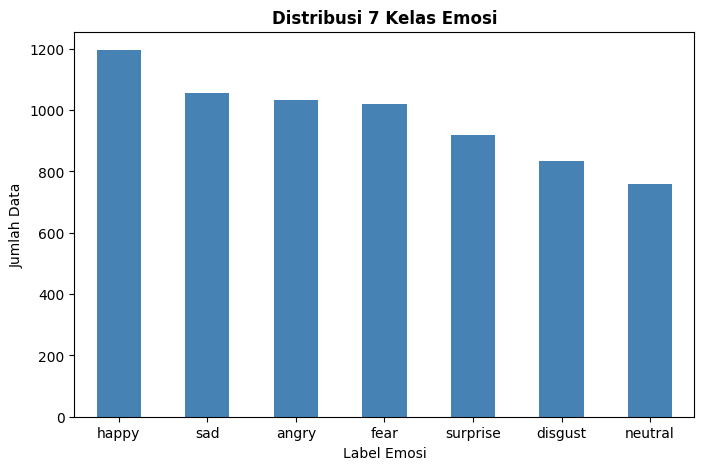

In [ ]:
# visualisasi distribusi jumlah emosi dari ke-7 emosi

data_df['label_emosi'].value_counts().plot(kind='bar', figsize=(8, 5), color='steelblue')

plt.title('Distribusi 7 Kelas Emosi', fontweight='bold')
plt.xlabel('Label Emosi')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)

plt.show()

> **Insight** : dapat diketahui bahwa dataset ini tidak memiliki jumlah teks yang sama dari ke-7 emosi tersebut. Tetapi, dari jumlah masing masing emosi tersebut masih tergolong balance dan tidak perlu dilakukannya balancing data kembali. Karena apabila dilalukan balancing data pada teknik feature engineering, maka data bisa saja terjadinya overfitting pada saat training dan testing nantinya

#### **4. Cek Kata Kunci Emosi dari 7 Kelas Emosi**

In [ ]:
kamus_emosi = {
    'happy': ['seneng', 'senang', 'cinta', 'bahagia', 'bersyukur', 'alhamdulillah', 'puji tuhan','akhirnya', 'makasih', 'terima kasih', 'mantap', 'happy', 'cihuy', 'cute', 'senang','ketawa', 'ngakak', 'tertawa', 'lucu', 'syukur', 'happy'],
    'sad': ['sedih', 'kecewa', 'nangis', 'sakit hati', 'hancur', 'tega', 'sad','nyesek', 'berduka', 'mewek', 'nyesel', 'lemes', 'sesak', 'galau','gamon', 'kasihan','kasian', 'kehilangan', 'menyesal', 'nyesel','sesek', 'trauma', 'sad'],
    'disgust': ['jijik', 'muak', 'najis', 'enek', 'iyuh', 'ew', 'ewh', 'mual','ga banget', 'geli', 'gelay', 'disgust', 'disgusting', 'jorok', 'ilfeel'],
    'angry': ['marah', 'benci', 'kesel', 'kesal', 'goblok', 'anjing', 'sialan', 'tolol','sampah', 'gila', 'stress', 'goblok', 'keterlaluan', 'berlebihan','brengsek', 'bajingan', 'naik pitam', 'naik darah', 'kurang ajar','goblok', 'kesal', 'murka', 'brengsek', 'berengsek', 'angry'],
    'fear': ['takut', 'ngeri', 'seram', 'cemas', 'khawatir', 'waspada', 'merinding', 'trauma','serem', 'bahaya', 'gemeteran', 'jantungan', 'horor', 'parno', 'deg degan','degdegan', 'ancaman', 'mengerikan', 'was was',  'gemeter', 'panik', 'ngilu', 'fear'],
    'surprise': ['kaget', 'sumpah', 'wow', 'shock', 'astaga', 'kok bisa', 'heran','lah', 'loh', 'plot twist', 'demi apa', 'seriusan', 'masa sih','terkejut', 'tercengang', 'syok', 'astaga', 'hah', 'takjub', 'buset','surprise'],
    'neutral': ['biasa', 'informasi', 'berita', 'kabar', 'jadwal', 'agenda', 'makan', 'minum']
}

In [ ]:
# cek kata yang sering muncul di setiap emosinya

def cek_distribusi_emosi(teks_series, kamus):
    semua_teks = " ".join(teks_series.astype(str)).lower()
    semua_teks = re.sub(r'[^a-z\s]', '', semua_teks)

    # tokenisasi sederhana
    tokens = semua_teks.split()

    hasil_eda = []

    for emosi, daftar_kata in kamus.items():
        kata_ditemukan = [kata for kata in tokens if kata in daftar_kata]

        # Hitung statistik
        total_kemunculan = len(kata_ditemukan)
        ragam_kata_unik = len(set(kata_ditemukan))

        rincian_kata = dict(Counter(kata_ditemukan).most_common(30))

        hasil_eda.append({
            'Emosi': emosi,
            'Total Kemunculan Kata': total_kemunculan,
            'Ragam Kata (Unik)': ragam_kata_unik,
            'Top 30 Kata': str(rincian_kata)
        })

    return pd.DataFrame(hasil_eda)

df_hasil_eda = cek_distribusi_emosi(data_df['full_text'], kamus_emosi)
display(df_hasil_eda)

,Emosi,Total Kemunculan Kata,Ragam Kata (Unik),Top 30 Kata
0,happy,1472,17,"{'seneng': 445, 'ngakak': 200, 'bahagia': 142,..."
1,sad,1318,19,"{'nangis': 602, 'sedih': 563, 'trauma': 47, 'k..."
2,disgust,1163,13,"{'najis': 387, 'jijik': 328, 'mual': 158, 'gel..."
3,angry,1182,17,"{'brengsek': 250, 'marah': 238, 'kesel': 145, ..."
4,fear,1406,21,"{'takut': 486, 'khawatir': 268, 'panik': 181, ..."
5,surprise,1506,16,"{'astaga': 412, 'wow': 241, 'terkejut': 216, '..."
6,neutral,352,8,"{'makan': 175, 'biasa': 37, 'minum': 33, 'beri..."


> **Insight** : dapat mengetahui kata kunci emosi yang sering muncul setelah labeling data tersebut.

# **5. TEKNIK FEATURE ENGINEERING**

Pada tahap feature engineering, kami menerapkan teknik labeling encoder, yang mana dari 7 kelas emosi tersebut akan dilabeli dengan type data numerik/integer, Berikut adalah mapping label_nomor 7 kelas emosi manusia:

----

> 1. Angry : 0
2. Disgust : 1
3. Fear : 2
4. Happy : 3
5. Neutral : 4
6. Sad : 5
7. Surprise : 6

Pada tahap teknik feature engineering ini, kami tidak melakukan Oversamplig/Undersampling dikarenakan walaupun data persebaran jumlah kelas emosi pada data ini tidak sama, tetapi persebaran kelas emosi tersebut masih dalam jangkauan dataset yang balance. Dikarenakan apabila memggunakan teknik Oversampling/Undersampling, bisa saja menyebabkan suatu model menjadi overfitting/underfitting.

**Import Modul**

In [ ]:
from sklearn.preprocessing import LabelEncoder

#### **1. Eksekusi Label Encoder**

In [ ]:
encoder = LabelEncoder()
data_df['label_angka'] = encoder.fit_transform(data_df['label_emosi'])
kamus_label = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

for emosi, angka in kamus_label.items():
    print(f"Emosi '{emosi}' diubah menjadi angka: {angka}")

display(data_df[['full_text', 'normalisasi_teks', 'teks_stemming', 'label_emosi','label_angka']].sample(10, random_state=42))

Emosi 'angry' diubah menjadi angka: 0
Emosi 'disgust' diubah menjadi angka: 1
Emosi 'fear' diubah menjadi angka: 2
Emosi 'happy' diubah menjadi angka: 3
Emosi 'neutral' diubah menjadi angka: 4
Emosi 'sad' diubah menjadi angka: 5
Emosi 'surprise' diubah menjadi angka: 6


,full_text,normalisasi_teks,teks_stemming,label_emosi,label_angka
239,mestilah masa aku tengah tergesagesa unlock ma...,mestilah masa aku tengah tergesagesa unlock ma...,mesti masa aku tengah tergesagesa unlock mangg...,neutral,4
6899,asli dah najis,asli deh najis,asli deh najis,disgust,1
6757,gua lebih ngeri kalo misal user keotsune mimpi...,gua lebih ngeri kalo misal user keotsune mimpi...,gua lebih ngeri kalo misal user keotsune mimpi...,angry,0
5964,panik lah anjir,panik lah anjir,panik lah anjir,fear,2
2642,kok cemas bukannya sebelum muncul sppi segala ...,kok cemas bukannya sebelum muncul sppi segala ...,kok cemas bukan belum muncul sppi segala macam...,angry,0
3261,sehat terus ya kak dan bahagia selalu,sehat terus ya kak dan bahagia selalu,sehat terus ya kak dan bahagia selalu,happy,3
6939,emg geng paling munafik dan rendah ya go green...,memang geng paling munafik dan rendah ya go gr...,memang geng paling munafik dan rendah ya go gr...,disgust,1
5113,kalo dikasih tau nanti kita tercengang kalo ga...,kalo dikasih tau nanti kita tercengang kalo en...,kalo kasih tau nanti kita cengang kalo enggak ...,surprise,6
1595,mual anjirrrrr,mual anjirrrrr,mual anjirrrrr,disgust,1
4364,mengggg aku sedih lah isi tl ku penuh sama ora...,mengggg aku sedih lah isi tl ku penuh sama ora...,mengggg aku sedih lah isi tl ku penuh sama ora...,sad,5


> **Insight:** Seluruh kelas yang sudah berlabelkan 7 emosi tersebut sudah dilakukannya proses labeling encoder, yang mana terdapat kolom baru, yaitu 'label_angka' yang berisikan numerik (int) yang merepresentasikan masing masing kelas emosi tersebut dan sesuai dengan mapping label encoder yang sudah dirancang sebelumnya.

# **6. VISUALISASI DATA**

Melalui Visualisasi data ini, **maka akan menjawab seluruh pertanyaan bisnis yang dapat diukur**

**Import Modul**

In [ ]:
import nltk
from wordcloud import WordCloud
from nltk.corpus import stopwords

**Melakukan penghapusan stopword sebelum memvisualisasikan persebaran kata kunci dari kelas emosi**

In [ ]:
# Download kamus stopword
nltk.download('stopwords')

list_stopwords = set(stopwords.words('indonesian'))
# Tamabahan kata gaul
list_stopwords.update(['gua', 'gue', 'lu','gw','lo', 'aja', 'nya', 'kalo', 'sama', 'buat',
                       'aku', 'di', 'ke', 'dari', 'ini', 'itu', 'sih', 'ya', 'kayak', 'deh', 'orang'])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


> **Insight :** Menghapus stopword yang dapat menggangu visualisasi yang menampilkan kata kunci emosi yang paling sering muncul pada masing masing kelas emosi

#### 1. Kata emosi apa yang paling sering muncul pada emosi **angry?**

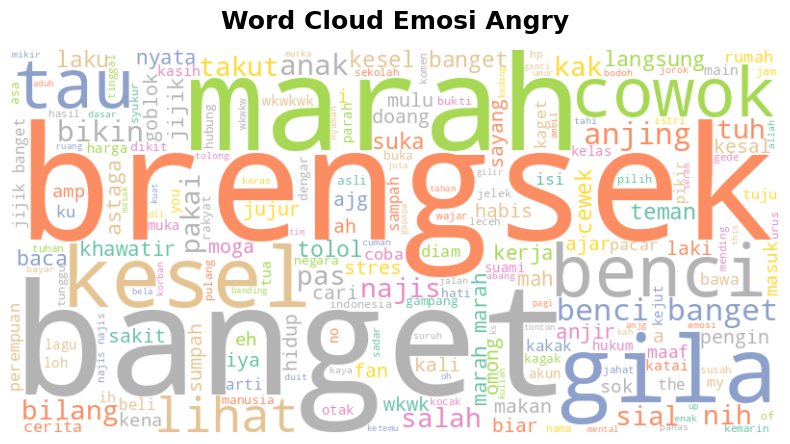

In [ ]:
# WordCloud

teks_angry = " ".join(data_df[data_df['label_emosi'] == 'angry']['teks_stemming'].astype(str))

wc_angry = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=list_stopwords,
    colormap='Set2'
).generate(teks_angry)

plt.figure(figsize=(10, 5))
plt.imshow(wc_angry, interpolation='bilinear')
plt.title('Word Cloud Emosi Angry', fontsize=18, fontweight='bold', pad=15)
plt.axis('off')
plt.show()

#### 2. Kata emosi apa yang paling sering muncul pada emosi **disgust?**

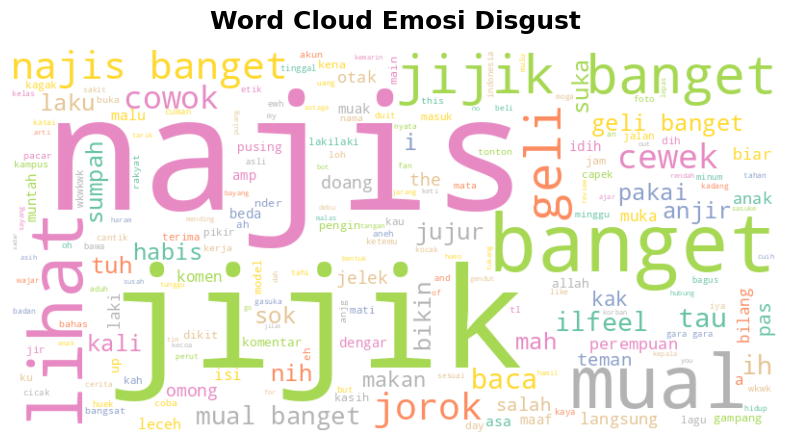

In [ ]:
# WordCloud

teks_disgust = " ".join(data_df[data_df['label_emosi'] == 'disgust']['teks_stemming'].astype(str))

wc_disgust = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=list_stopwords,
    colormap='Set2'
).generate(teks_disgust)

plt.figure(figsize=(10, 5))
plt.imshow(wc_disgust, interpolation='bilinear')
plt.title('Word Cloud Emosi Disgust', fontsize=18, fontweight='bold', pad=15)
plt.axis('off')
plt.show()

#### 3. Kata emosi apa yang paling sering muncul pada emosi **fear?**

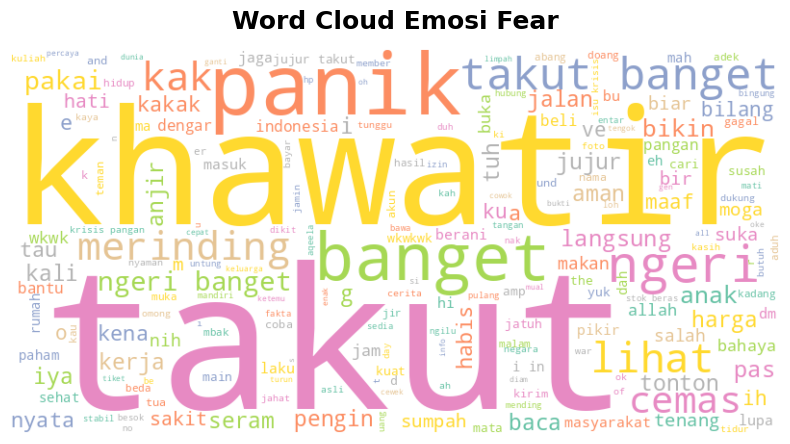

In [ ]:
# WordCloud

teks_fear = " ".join(data_df[data_df['label_emosi'] == 'fear']['teks_stemming'].astype(str))

wc_fear = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=list_stopwords,
    colormap='Set2'
).generate(teks_fear)

plt.figure(figsize=(10, 5))
plt.imshow(wc_fear, interpolation='bilinear')
plt.title('Word Cloud Emosi Fear', fontsize=18, fontweight='bold', pad=15)
plt.axis('off')
plt.show()

#### 4. Kata emosi apa yang paling sering muncul pada emosi **happy?**

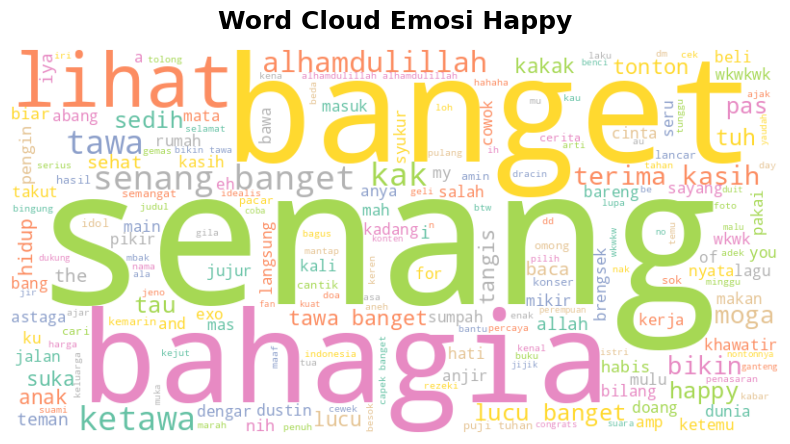

In [ ]:
# WordCloud

teks_happy = " ".join(data_df[data_df['label_emosi'] == 'happy']['teks_stemming'].astype(str))

wc_happy = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=list_stopwords,
    colormap='Set2'
).generate(teks_happy)

plt.figure(figsize=(10, 5))
plt.imshow(wc_happy, interpolation='bilinear')
plt.title('Word Cloud Emosi Happy', fontsize=18, fontweight='bold', pad=15)
plt.axis('off')
plt.show()

#### 5. Kata emosi apa yang paling sering muncul pada emosi **neutral?**

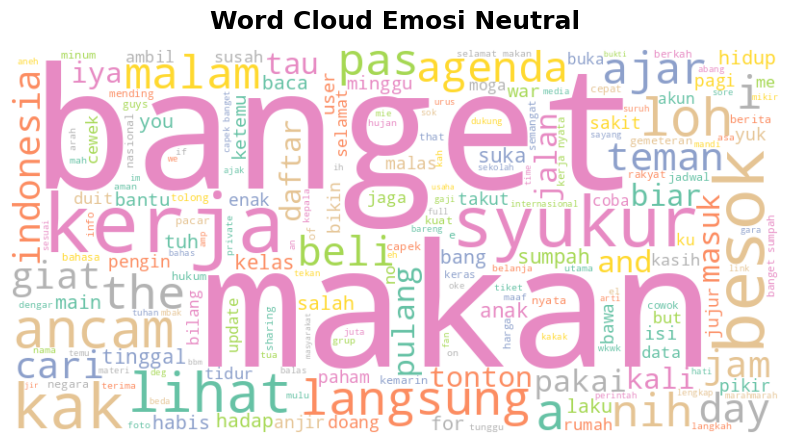

In [ ]:
# WordCloud

teks_neutral = " ".join(data_df[data_df['label_emosi'] == 'neutral']['teks_stemming'].astype(str))

wc_neutral = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=list_stopwords,
    colormap='Set2'
).generate(teks_neutral)

plt.figure(figsize=(10, 5))
plt.imshow(wc_neutral, interpolation='bilinear')
plt.title('Word Cloud Emosi Neutral', fontsize=18, fontweight='bold', pad=15)
plt.axis('off')
plt.show()

#### 6. Kata emosi apa yang paling sering muncul pada emosi **sad?**

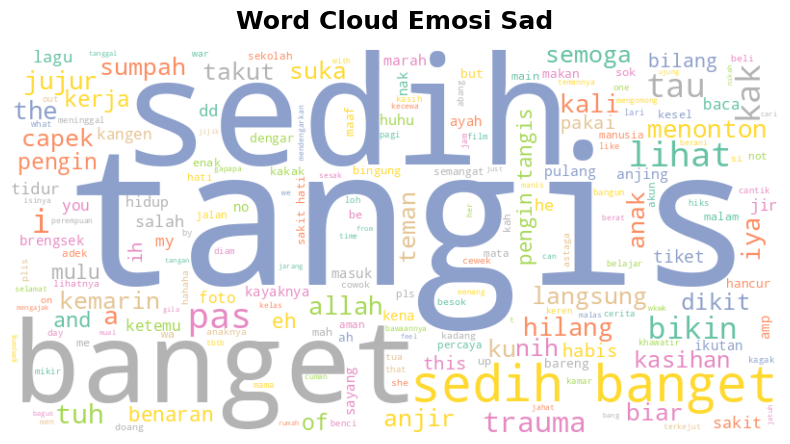

In [ ]:
# WordCloud

teks_sad = " ".join(data_df[data_df['label_emosi'] == 'sad']['normalisasi_teks'].astype(str))

wc_sad = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=list_stopwords,
    colormap='Set2'
).generate(teks_sad)

plt.figure(figsize=(10, 5))
plt.imshow(wc_sad, interpolation='bilinear')
plt.title('Word Cloud Emosi Sad', fontsize=18, fontweight='bold', pad=15)
plt.axis('off')
plt.show()

#### 7. Kata emosi apa yang paling sering muncul pada emosi **surprise?**

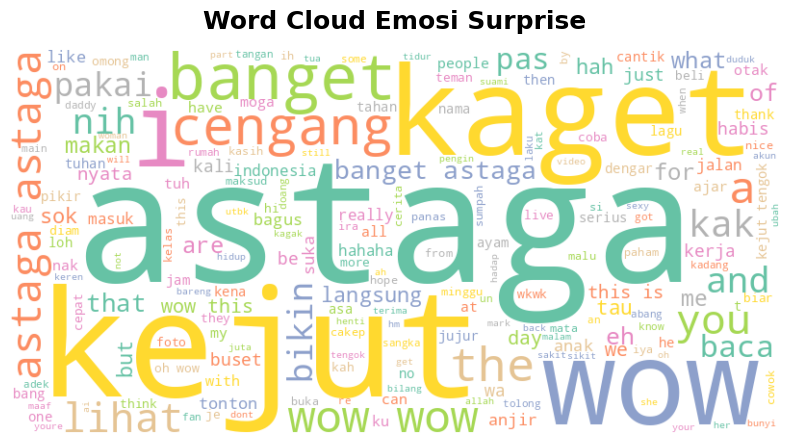

In [ ]:
# WordCloud

teks_surprise = " ".join(data_df[data_df['label_emosi'] == 'surprise']['teks_stemming'].astype(str))

wc_surprise = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=list_stopwords,
    colormap='Set2'
).generate(teks_surprise)

plt.figure(figsize=(10, 5))
plt.imshow(wc_surprise, interpolation='bilinear')
plt.title('Word Cloud Emosi Surprise', fontsize=18, fontweight='bold', pad=15)
plt.axis('off')
plt.show()

# **7. KESIMPULAN**

Kesimpulan dari proses cleaning hingga finalisasi dataset ini adalah :
- Dataset Final

# **8. DOWNLOAD FINAL DATA**

In [ ]:
from google.colab import files

nama_file = 'Final Dataset.csv'
data_df.to_csv(nama_file, index=False)

# files.download(nama_file)